# Preference Model Transcript Comparison

Take 60 pairwise comparisons from the kidney data (normalized features) and record what each preference model responds:
- **Frame model** (our model)
- **Bradley-Terry** (logistic/sigmoid link)
- **Thurstone-Mosteller** (probit link)
- **Max-margin** (linear utility)

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import norm as normal_dist
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from core import (
    Patient, PairwiseQuery, FEATURE_NAMES, FEATURE_RANGES,
    compute_frame_gaps, compute_aggregate_scores,
)

sns.set_style('whitegrid')
np.random.seed(42)

In [14]:
# Algorithm parameters
TAU = 0.1  # Intensity threshold
TAU_PRIME = 0.1  # Resolvability threshold
LAMBDA_X = 1.0  # Query scaling factor (can be a function later)


## Load and normalize kidney data

In [15]:
df = pd.read_csv('kidney_pairwise_data.csv')

# Normalize features to [0, 1]
feature_cols_left = ['l_elderlyDep', 'l_lifeYearsGained', 'l_obesity', 'l_weeklyWorkhours', 'l_yearsWaiting']
feature_cols_right = ['r_elderlyDep', 'r_lifeYearsGained', 'r_obesity', 'r_weeklyWorkhours', 'r_yearsWaiting']

for l_col, r_col, fname in zip(feature_cols_left, feature_cols_right, FEATURE_NAMES):
    lo, hi = FEATURE_RANGES[fname]
    span = hi - lo if hi != lo else 1.0
    df[l_col] = (df[l_col] - lo) / span
    df[r_col] = (df[r_col] - lo) / span

print('Feature normalization (min-max to [0,1]):')
for fname in FEATURE_NAMES:
    lo, hi = FEATURE_RANGES[fname]
    print(f'  {fname}: [{lo}, {hi}] -> [0, 1]')

print(f'\nTotal rows: {len(df)}')
print(f'Unique people: {df["id"].nunique()}')

Feature normalization (min-max to [0,1]):
  elderlyDep: [0, 5] -> [0, 1]
  lifeYearsGained: [0, 25] -> [0, 1]
  obesity: [0, 5] -> [0, 1]
  weeklyWorkhours: [0, 50] -> [0, 1]
  yearsWaiting: [1, 10] -> [0, 1]

Total rows: 33024
Unique people: 82


## Extract 60 unique pairwise queries

In [16]:
def row_to_query(row):
    """Convert a dataframe row to a PairwiseQuery with normalized features."""
    left = Patient(
        elderlyDep=row['l_elderlyDep'],
        lifeYearsGained=row['l_lifeYearsGained'],
        obesity=row['l_obesity'],
        weeklyWorkhours=row['l_weeklyWorkhours'],
        yearsWaiting=row['l_yearsWaiting']
    )
    right = Patient(
        elderlyDep=row['r_elderlyDep'],
        lifeYearsGained=row['r_lifeYearsGained'],
        obesity=row['r_obesity'],
        weeklyWorkhours=row['r_weeklyWorkhours'],
        yearsWaiting=row['r_yearsWaiting']
    )
    return PairwiseQuery(left, right)


# Get 60 unique pairwise queries by sampling distinct pair IDs
unique_pairs = df.drop_duplicates(subset='pairid')
sampled = unique_pairs.sample(n=60, random_state=42)

queries = []
for _, row in sampled.iterrows():
    queries.append(row_to_query(row))

print(f'Selected {len(queries)} unique pairwise queries')
print(f'\nExample query:')
print(queries[0])

Selected 60 unique pairwise queries

Example query:
Query:
  LEFT:  Patient(elder=0.6, life=0.2, obesity=0.2, work=1.0, wait=0.0)
  RIGHT: Patient(elder=0.2, life=0.8, obesity=0.0, work=1.0, wait=0.2222222222222222)


## Define preference models

In [17]:
def predict_frame(query, weights, tau=TAU, lambda_x=LAMBDA_X, tau_prime=TAU_PRIME):
    """Frame model prediction."""
    gaps, active_frames = compute_frame_gaps(query, lambda_x, tau)
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)
    if r_omega < tau:
        return 'indifferent'
    if np.abs(delta_omega) < tau_prime * r_omega:
        return 'incomparable'
    elif delta_omega >= tau_prime * r_omega:
        return 'left'
    elif delta_omega <= -tau_prime * r_omega:
        return 'right'
    return 'indifferent'


def predict_bt(query, weights, threshold=0.5):
    """Bradley-Terry: P(left) = sigmoid(w . delta_x)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    logit = np.dot(weights, delta_x)
    prob_left = 1.0 / (1.0 + np.exp(-logit))
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_thurstone(query, weights, sigma=1.0, threshold=0.5):
    """Thurstone-Mosteller (Case V): P(left) = Phi(w . delta_x / sigma)."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    z = np.dot(weights, delta_x) / sigma
    prob_left = normal_dist.cdf(z)
    if prob_left > threshold:
        return 'left'
    elif prob_left < 1.0 - threshold:
        return 'right'
    else:
        return 'indifferent'


def predict_max_margin(query, weights, margin=0.0):
    """Max-margin: left if w . delta_x > margin, right if < -margin, else indifferent."""
    delta_x = query.patient_left.to_array() - query.patient_right.to_array()
    score = np.dot(weights, delta_x)
    if score > margin:
        return 'left'
    elif score < -margin:
        return 'right'
    else:
        return 'indifferent'

## Run all models on the 60 queries

In [18]:
# Sample weight vector from unit sphere (allows negative weights)
z = np.random.randn(len(FEATURE_NAMES))
weights = z / np.linalg.norm(z)

print(f'Weight vector (unit sphere): {dict(zip(FEATURE_NAMES, weights))}')
print(f'||w||_2 = {np.linalg.norm(weights):.4f}')
print(f'\nModel parameters:')
print(f'  Frame:    tau={TAU}, tau_prime={TAU_PRIME}, lambda_x={LAMBDA_X}')
print(f'  BT:       threshold=0.5')
print(f'  Thurstone: sigma=1.0, threshold=0.5')
print(f'  Max-margin: margin=0.0')
print()

records = []
for i, query in enumerate(queries):
    left_arr = query.patient_left.to_array()
    right_arr = query.patient_right.to_array()
    delta_x = left_arr - right_arr

    frame_resp = predict_frame(query, weights)
    bt_resp = predict_bt(query, weights)
    thurstone_resp = predict_thurstone(query, weights)
    maxmargin_resp = predict_max_margin(query, weights)

    records.append({
        'query_idx': i,
        **{f'left_{fn}': left_arr[j] for j, fn in enumerate(FEATURE_NAMES)},
        **{f'right_{fn}': right_arr[j] for j, fn in enumerate(FEATURE_NAMES)},
        **{f'delta_{fn}': delta_x[j] for j, fn in enumerate(FEATURE_NAMES)},
        'w_dot_delta': np.dot(weights, delta_x),
        'frame': frame_resp,
        'bradley_terry': bt_resp,
        'thurstone': thurstone_resp,
        'max_margin': maxmargin_resp,
    })

print(weights)
results = pd.DataFrame(records)
print(f'Collected responses for {len(results)} queries')

Weight vector (unit sphere): {'elderlyDep': 0.28396231829254587, 'lifeYearsGained': -0.0790431503907248, 'obesity': 0.370271589193923, 'weeklyWorkhours': 0.8706880732762329, 'yearsWaiting': -0.13386116485583224}
||w||_2 = 1.0000

Model parameters:
  Frame:    tau=0.1, tau_prime=0.1, lambda_x=1.0
  BT:       threshold=0.5
  Thurstone: sigma=1.0, threshold=0.5
  Max-margin: margin=0.0

[ 0.28396232 -0.07904315  0.37027159  0.87068807 -0.13386116]
Collected responses for 60 queries


## Response summary

In [19]:
# Debug query 2: why does frame say 'indifferent' while others say 'left'?
q = queries[2]
left_arr = q.patient_left.to_array()
right_arr = q.patient_right.to_array()
delta_x = left_arr - right_arr

print("Query 2 features (normalized):")
for j, fn in enumerate(FEATURE_NAMES):
    print(f"  {fn:20s}  left={left_arr[j]:.4f}  right={right_arr[j]:.4f}  gap={delta_x[j]:+.4f}")

print(f"\nWeights: {dict(zip(FEATURE_NAMES, [f'{w:+.4f}' for w in weights]))}")
print(f"w . delta_x = {np.dot(weights, delta_x):+.6f}")

# Frame model internals
gaps, active_frames = compute_frame_gaps(q, LAMBDA_X, TAU)
print(f"\nFrame model internals:")
print(f"  tau = {TAU}")
for j, fn in enumerate(FEATURE_NAMES):
    status = "ACTIVE" if j in active_frames else "inactive"
    # print(f"  {fn:20s}  |gap|={abs(gaps[j]):.4f}  {'>=':s if j in active_frames else '< '} tau={TAU}  -> {status}")

print(f"\n  Active frames: {sorted(active_frames)}")

if len(active_frames) > 0:
    delta_omega, r_omega = compute_aggregate_scores(gaps, weights, active_frames)
    print(f"  delta(omega) = {delta_omega:+.6f}  (weighted signed sum over active frames)")
    print(f"  r(omega)     = {r_omega:.6f}  (weighted intensity over active frames)")
    print(f"  r(omega) < tau? {r_omega} < {TAU} -> {r_omega < TAU}")
    if r_omega >= TAU:
        print(f"  |delta|/r    = {abs(delta_omega)/r_omega:.4f}  vs tau'={TAU_PRIME}")
else:
    print(f"  No active frames -> r(omega) = 0 < tau = {TAU} -> INDIFFERENT")
    print(f"\n  The frame model ignores features with |gap| < tau.")
    print(f"  The other models use ALL features regardless of gap size.")

Query 2 features (normalized):
  elderlyDep            left=0.4000  right=0.6000  gap=-0.2000
  lifeYearsGained       left=1.0000  right=0.8000  gap=+0.2000
  obesity               left=0.2000  right=0.2000  gap=+0.0000
  weeklyWorkhours       left=0.8000  right=0.8000  gap=+0.0000
  yearsWaiting          left=0.0000  right=0.6667  gap=-0.6667

Weights: {'elderlyDep': '+0.2840', 'lifeYearsGained': '-0.0790', 'obesity': '+0.3703', 'weeklyWorkhours': '+0.8707', 'yearsWaiting': '-0.1339'}
w . delta_x = +0.016640

Frame model internals:
  tau = 0.1

  Active frames: [0, 1, 4]
  delta(omega) = +0.016640  (weighted signed sum over active frames)
  r(omega)     = -0.048257  (weighted intensity over active frames)
  r(omega) < tau? -0.04825694299019063 < 0.1 -> True


In [20]:
model_cols = ['frame', 'bradley_terry', 'thurstone', 'max_margin']

print('Response counts per model:')
print('=' * 55)
for col in model_cols:
    counts = results[col].value_counts()
    print(f'\n{col}:')
    for resp in ['left', 'right', 'indifferent', 'incomparable']:
        print(f'  {resp:15s} {counts.get(resp, 0):3d}')

Response counts per model:

frame:
  left             20
  right            31
  indifferent       6
  incomparable      3

bradley_terry:
  left             24
  right            36
  indifferent       0
  incomparable      0

thurstone:
  left             24
  right            36
  indifferent       0
  incomparable      0

max_margin:
  left             24
  right            36
  indifferent       0
  incomparable      0


In [21]:
# Pairwise agreement between models
print('Pairwise agreement rates:')
print('=' * 55)
for i, m1 in enumerate(model_cols):
    for m2 in model_cols[i+1:]:
        agree = (results[m1] == results[m2]).mean()
        print(f'  {m1:15s} vs {m2:15s}: {agree:.1%}')

Pairwise agreement rates:
  frame           vs bradley_terry  : 85.0%
  frame           vs thurstone      : 85.0%
  frame           vs max_margin     : 85.0%
  bradley_terry   vs thurstone      : 100.0%
  bradley_terry   vs max_margin     : 100.0%
  thurstone       vs max_margin     : 100.0%


In [22]:
# Show the full transcript side by side
display_cols = ['query_idx', 'w_dot_delta', 'frame', 'bradley_terry', 'thurstone', 'max_margin']
print(results[display_cols].to_string(index=False))

 query_idx  w_dot_delta        frame bradley_terry thurstone max_margin
         0     0.264812         left          left      left       left
         1    -0.505151        right         right     right      right
         2     0.016640  indifferent          left      left       left
         3     0.181991         left          left      left       left
         4    -0.472040        right         right     right      right
         5    -0.830721        right         right     right      right
         6    -0.310410        right         right     right      right
         7    -0.280409        right         right     right      right
         8    -0.272973        right         right     right      right
         9     0.189946         left          left      left       left
        10    -0.508432        right         right     right      right
        11     0.556731         left          left      left       left
        12    -0.043913        right         right     right    

In [23]:
# Highlight disagreements
def all_agree(row):
    responses = [row[c] for c in model_cols]
    return len(set(responses)) == 1

results['all_agree'] = results.apply(all_agree, axis=1)
n_agree = results['all_agree'].sum()
n_disagree = len(results) - n_agree

print(f'All 4 models agree: {n_agree}/{len(results)} ({n_agree/len(results):.1%})')
print(f'At least one disagrees: {n_disagree}/{len(results)} ({n_disagree/len(results):.1%})')

if n_disagree > 0:
    print(f'\nDisagreement queries:')
    print(results.loc[~results['all_agree'], display_cols].to_string(index=False))

All 4 models agree: 51/60 (85.0%)
At least one disagrees: 9/60 (15.0%)

Disagreement queries:
 query_idx  w_dot_delta        frame bradley_terry thurstone max_margin
         2     0.016640  indifferent          left      left       left
        13    -0.036412  indifferent         right     right      right
        15    -0.009784 incomparable         right     right      right
        24    -0.040923 incomparable         right     right      right
        25     0.014955 incomparable          left      left       left
        29    -0.027046  indifferent         right     right      right
        30    -0.267119  indifferent         right     right      right
        41     0.157270  indifferent          left      left       left
        56     0.072601  indifferent          left      left       left


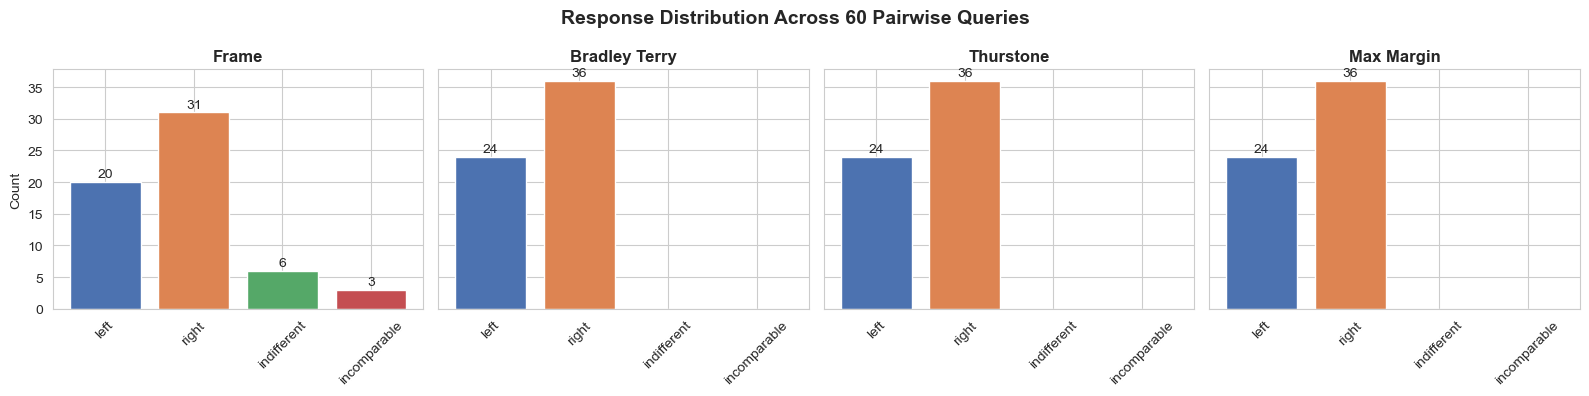

In [24]:
# Visualize: response distribution per model
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
response_order = ['left', 'right', 'indifferent', 'incomparable']
colors = {'left': '#4c72b0', 'right': '#dd8452', 'indifferent': '#55a868', 'incomparable': '#c44e52'}

for ax, col in zip(axes, model_cols):
    counts = results[col].value_counts()
    vals = [counts.get(r, 0) for r in response_order]
    bars = ax.bar(response_order, vals, color=[colors[r] for r in response_order])
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylabel('Count' if col == model_cols[0] else '')
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, str(v),
                    ha='center', va='bottom', fontsize=10)

fig.suptitle('Response Distribution Across 60 Pairwise Queries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()